** Yes, in machine learning and computer science, tensors are N-dimensional arrays, but in pure mathematics, a tensor is a geometric object that is only represented by an array in a specific coordinate system**

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5 

In [3]:
f(3)

20

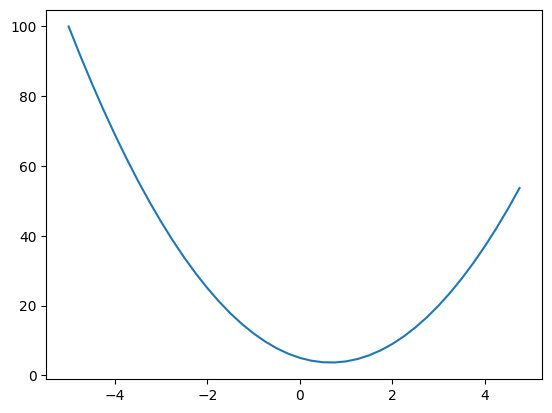

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.0000001
x = 2/3
(f(x+h) - f(x))/h

2.9753977059954195e-07

In [2]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
c += h
d2 = a * b + c

print("d1", d1)
print("d2", d2)
print("slope", (d2 - d1) / h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [3]:
import math

class value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self, other):
        other = other if isinstance(other, value) else value(other)
        out = value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
        
    def __mul__(self, other):
        other = other if isinstance(other, value) else value(other)
        out = value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 
        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = value(self.data**other, (self,), f'**{other}')
    
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
    
        return out

    def __rmul__(self, other): # other * self
        return self * other
        
    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
        
    def __radd__(self, other): # other + self
        return self + other
        
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = value(math.exp(x), (self, ), 'exp')
        
        def _backward():
          self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [4]:
a = value(2.0)
b = value(3.0)

a - b

Value(data=-1.0)

In [5]:
import os
# Check your specific Graphviz installation path. 
# It is usually one of the following:
graphviz_path = r'C:\Program Files\Graphviz\bin' 
# graphviz_path = r'C:\Program Files (x86)\Graphviz\bin'

if graphviz_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + graphviz_path

In [6]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [7]:
# inputs x1,x2
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')
# weights w1,w2
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')
# bias of the neuron
b = value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()


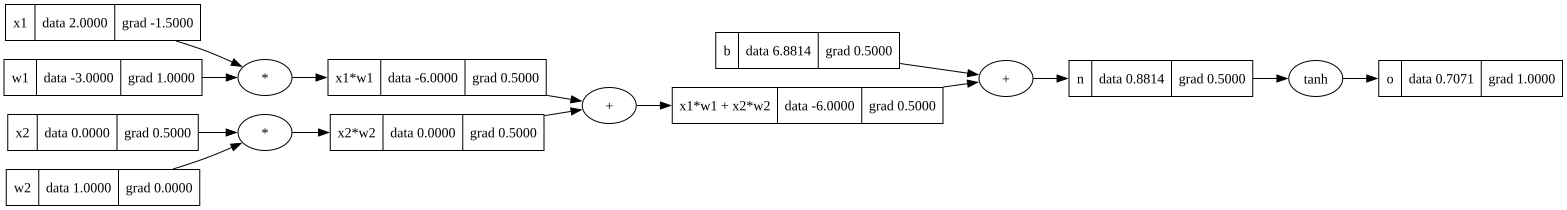

In [8]:
draw_dot(o)

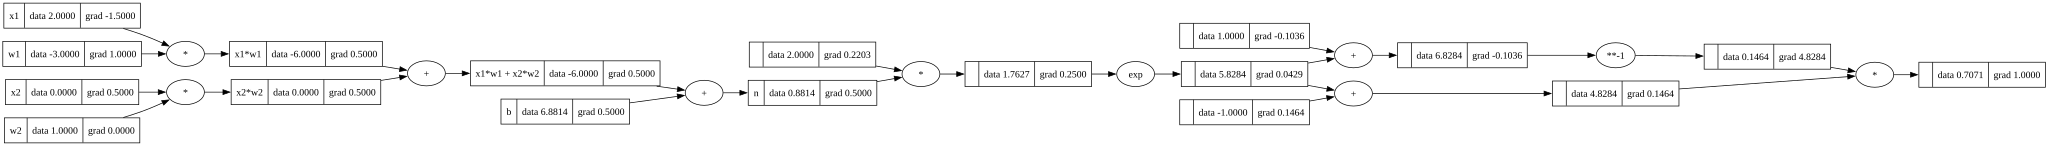

In [9]:
# inputs x1,x2
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')
# weights w1,w2
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')
# bias of the neuron
b = value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1) / (e + 1)

o.backward()
draw_dot(o)

In [10]:
import torch
import random

In [11]:
# constructing scaler valued 1 element tensors, by deflaut python thinks they dont req gradient so we have to explixitally tell that gradient is required

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [12]:
torch.tensor(([1,2,3], [4,5,6]))

tensor([[1, 2, 3],
        [4, 5, 6]])

In [13]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [14]:
class Neuron:
  
  def __init__(self, nin): #nin = total no. of inputs a neurin will take
    self.w = [value(random.uniform(-1,1)) for _ in range(nin)] #weight for ecah inputs
    self.b = value(random.uniform(-1,1)) # bias for each inptus


  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout): #nout : no. of outputs in this layer basically how many neurons u need in this layer
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts): #nouts r list of nouts it definesthe size of all the mlp
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [17]:
x = [2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.7791264169825415)

In [19]:
n.parameters()

[Value(data=0.15869632735826533),
 Value(data=-0.24722601322950766),
 Value(data=0.5548069463577101),
 Value(data=-0.3398593557121443),
 Value(data=0.18097700189874555),
 Value(data=0.9052907915212385),
 Value(data=-0.6078391303201676),
 Value(data=-0.3871860858596452),
 Value(data=-0.8482505677982479),
 Value(data=-0.020413561142084147),
 Value(data=0.32021508445176416),
 Value(data=-0.5497293846530955),
 Value(data=0.7474569667347903),
 Value(data=0.8917233318367181),
 Value(data=0.6927441411072797),
 Value(data=0.39007911272896756),
 Value(data=-0.23390834169300212),
 Value(data=0.3337673759839299),
 Value(data=0.9362568104303657),
 Value(data=-0.6097260865120135),
 Value(data=-0.275421269588519),
 Value(data=0.5089920473948712),
 Value(data=-0.5129769045745618),
 Value(data=0.7051984616424525),
 Value(data=0.06172038287224235),
 Value(data=0.08716278278049172),
 Value(data=0.210012073138927),
 Value(data=0.2701547089323961),
 Value(data=-0.7378577340536374),
 Value(data=0.793145831

In [20]:
len(n.parameters()) #therefore it has toatla of 41 parameters which we can tweak

41

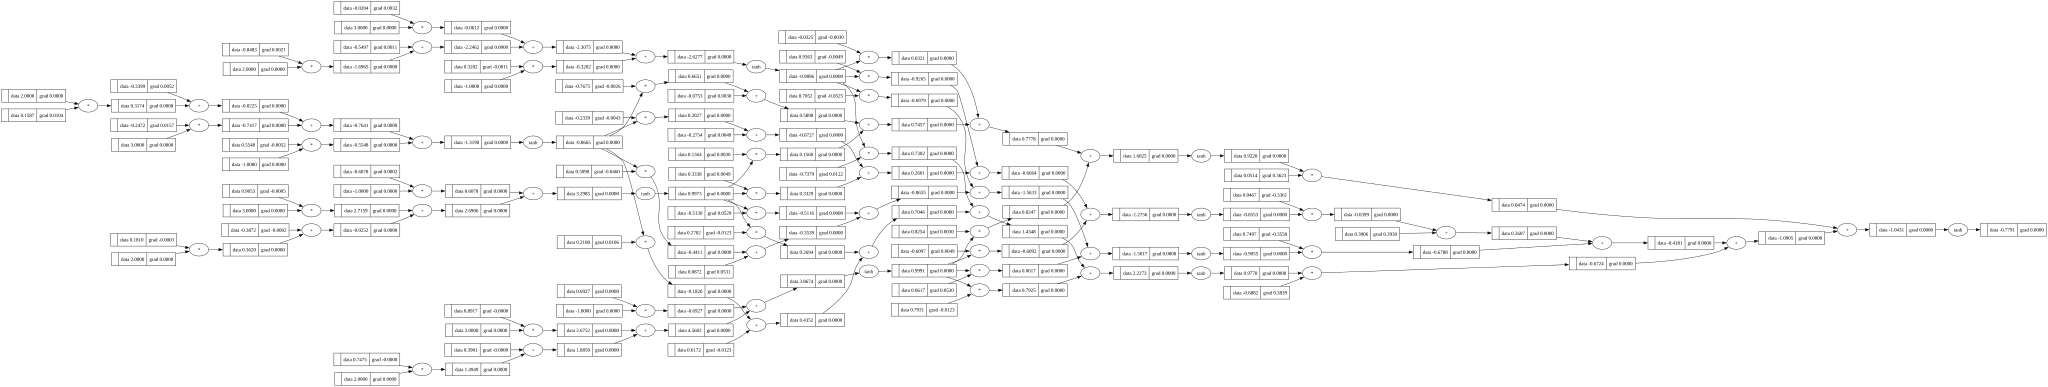

In [21]:
n(x).backward()
draw_dot(n(x))

In [22]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [23]:
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.7791264169825415),
 Value(data=-0.2859023931447066),
 Value(data=-0.4948592014713192),
 Value(data=-0.7679253945508706)]

loss is a single no. which we define that mesaured how well the neural network actually works

In [24]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.055953626757638)

In [25]:
loss.backward()

In [26]:
n.layers[0].neurons[0].w[0]

Value(data=0.15869632735826533)

In [27]:
n.layers[0].neurons[0].w[0].grad
#we can see the gradient of this here of this particular neuron of this particular neuron of this partcular layer is negative,
#we that its infulence on the loss is alsop negative

#so slighly inc this particular weight of this particular neuron of this layers would make the loss go down
#ans we have this info for all the neurons of all the layers

0.9034496080565676

In [28]:
n.layers[0].neurons[0].w[0].data
# as deriavtive of this neuron is -ve inc the wiegt of this neuron dec the loss and vice verse

0.15869632735826533

In [ ]:
draw_dot(loss)

In [40]:
for k in range(25):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 0.0037271089547590806
1 0.003699274315297231
2 0.0036718299832587953
3 0.003644767954701059
4 0.0036180804412381568
5 0.003591759862865704
6 0.0035657988410695883
7 0.003540190192205457
8 0.003514926921136892
9 0.0034900022151205636
10 0.00346540943792701
11 0.003441142124186986
12 0.0034171939739528695
13 0.0033935588474661347
14 0.003370230760121398
15 0.0033472038776188374
16 0.003324472511296802
17 0.0033020311136365533
18 0.003279874273932217
19 0.003257996714118535
20 0.003236393284750118
21 0.003215058961125555
22 0.0031939888395503017
23 0.0031731781337331097
24 0.0031526221713096105


In [41]:
ypred

[Value(data=0.9734975190330112),
 Value(data=-0.97579550323174),
 Value(data=-0.9687852184787711),
 Value(data=0.970166789903176)]